# Предиктивная аналитика
# Лабораторная работа №2
# «Виртуальный датчик для контроля процесса обжига в печи»
# Разведочный анализ данных (EDA)




In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import shap

from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from pandas.plotting import autocorrelation_plot

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Загрузка данных
data   = pd.read_csv('data_train.csv')
target = pd.read_csv('target_train.csv')
data_test        = pd.read_csv('data_test_small.csv')
target_test_raw  = pd.read_csv('target_test_small.csv')

data['datetime']           = pd.to_datetime(data['datetime'])
data.set_index('datetime', inplace=True)
target['Дата']             = pd.to_datetime(target['Дата'])
target.set_index('Дата', inplace=True)
data_test['datetime']      = pd.to_datetime(data_test['datetime'])
data_test.set_index('datetime', inplace=True)
target_test_raw['Дата']    = pd.to_datetime(target_test_raw['Дата'])
target_test_raw.set_index('Дата', inplace=True)

print(f"Train data:   {data.shape}  | {data.index.min()} -> {data.index.max()}")
print(f"Train target: {target.shape}")
print(f"Test data:    {data_test.shape}")
print(f"Test target:  {target_test_raw.shape}")

Train data:   (319546, 16)  | 2019-03-01 00:01:00 -> 2019-10-07 19:58:00
Train target: (1773, 1)
Test data:    (39943, 16)
Test target:  (318, 1)


# Разведочный анализ данных (EDA)

In [17]:
# Анализ пропусков
print("Процент пропусков по колонкам")
missing = (data.isnull().mean() * 100).round(2)
print(missing.to_string())

# Определяем порог для удаления «мёртвых» признаков
EMPTY_THRESH = 0.98
empty_cols = [c for c in data.columns if data[c].isnull().mean() > EMPTY_THRESH]
print(f"\nКолонки с >98% пропусков (удаляем): {empty_cols}")

data      = data.drop(columns=empty_cols)
data_test = data_test.drop(columns=[c for c in empty_cols if c in data_test.columns])
TELEMETRY_COLS = data.columns.tolist()
print(f"Итоговое число признаков телеметрии: {len(TELEMETRY_COLS)}")




Процент пропусков по колонкам
telemetry_0      0.01
telemetry_1      0.01
telemetry_2      0.01
telemetry_3      0.01
telemetry_4      0.04
telemetry_5      0.01
telemetry_6      0.01
telemetry_7      0.01
telemetry_8      0.01
telemetry_9      0.01
telemetry_10     0.01
telemetry_11     0.01
telemetry_12    99.34
telemetry_13    99.34
telemetry_14    99.34
telemetry_15    99.34

Колонки с >98% пропусков (удаляем): ['telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']
Итоговое число признаков телеметрии: 12


telemetry_12-15 имеют >98% пропусков - их можно исключить из анализа
telemetry_0-11  имеют < 0.05% пропусков

Index(['telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3',
       'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7',
       'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11'],
      dtype='object')


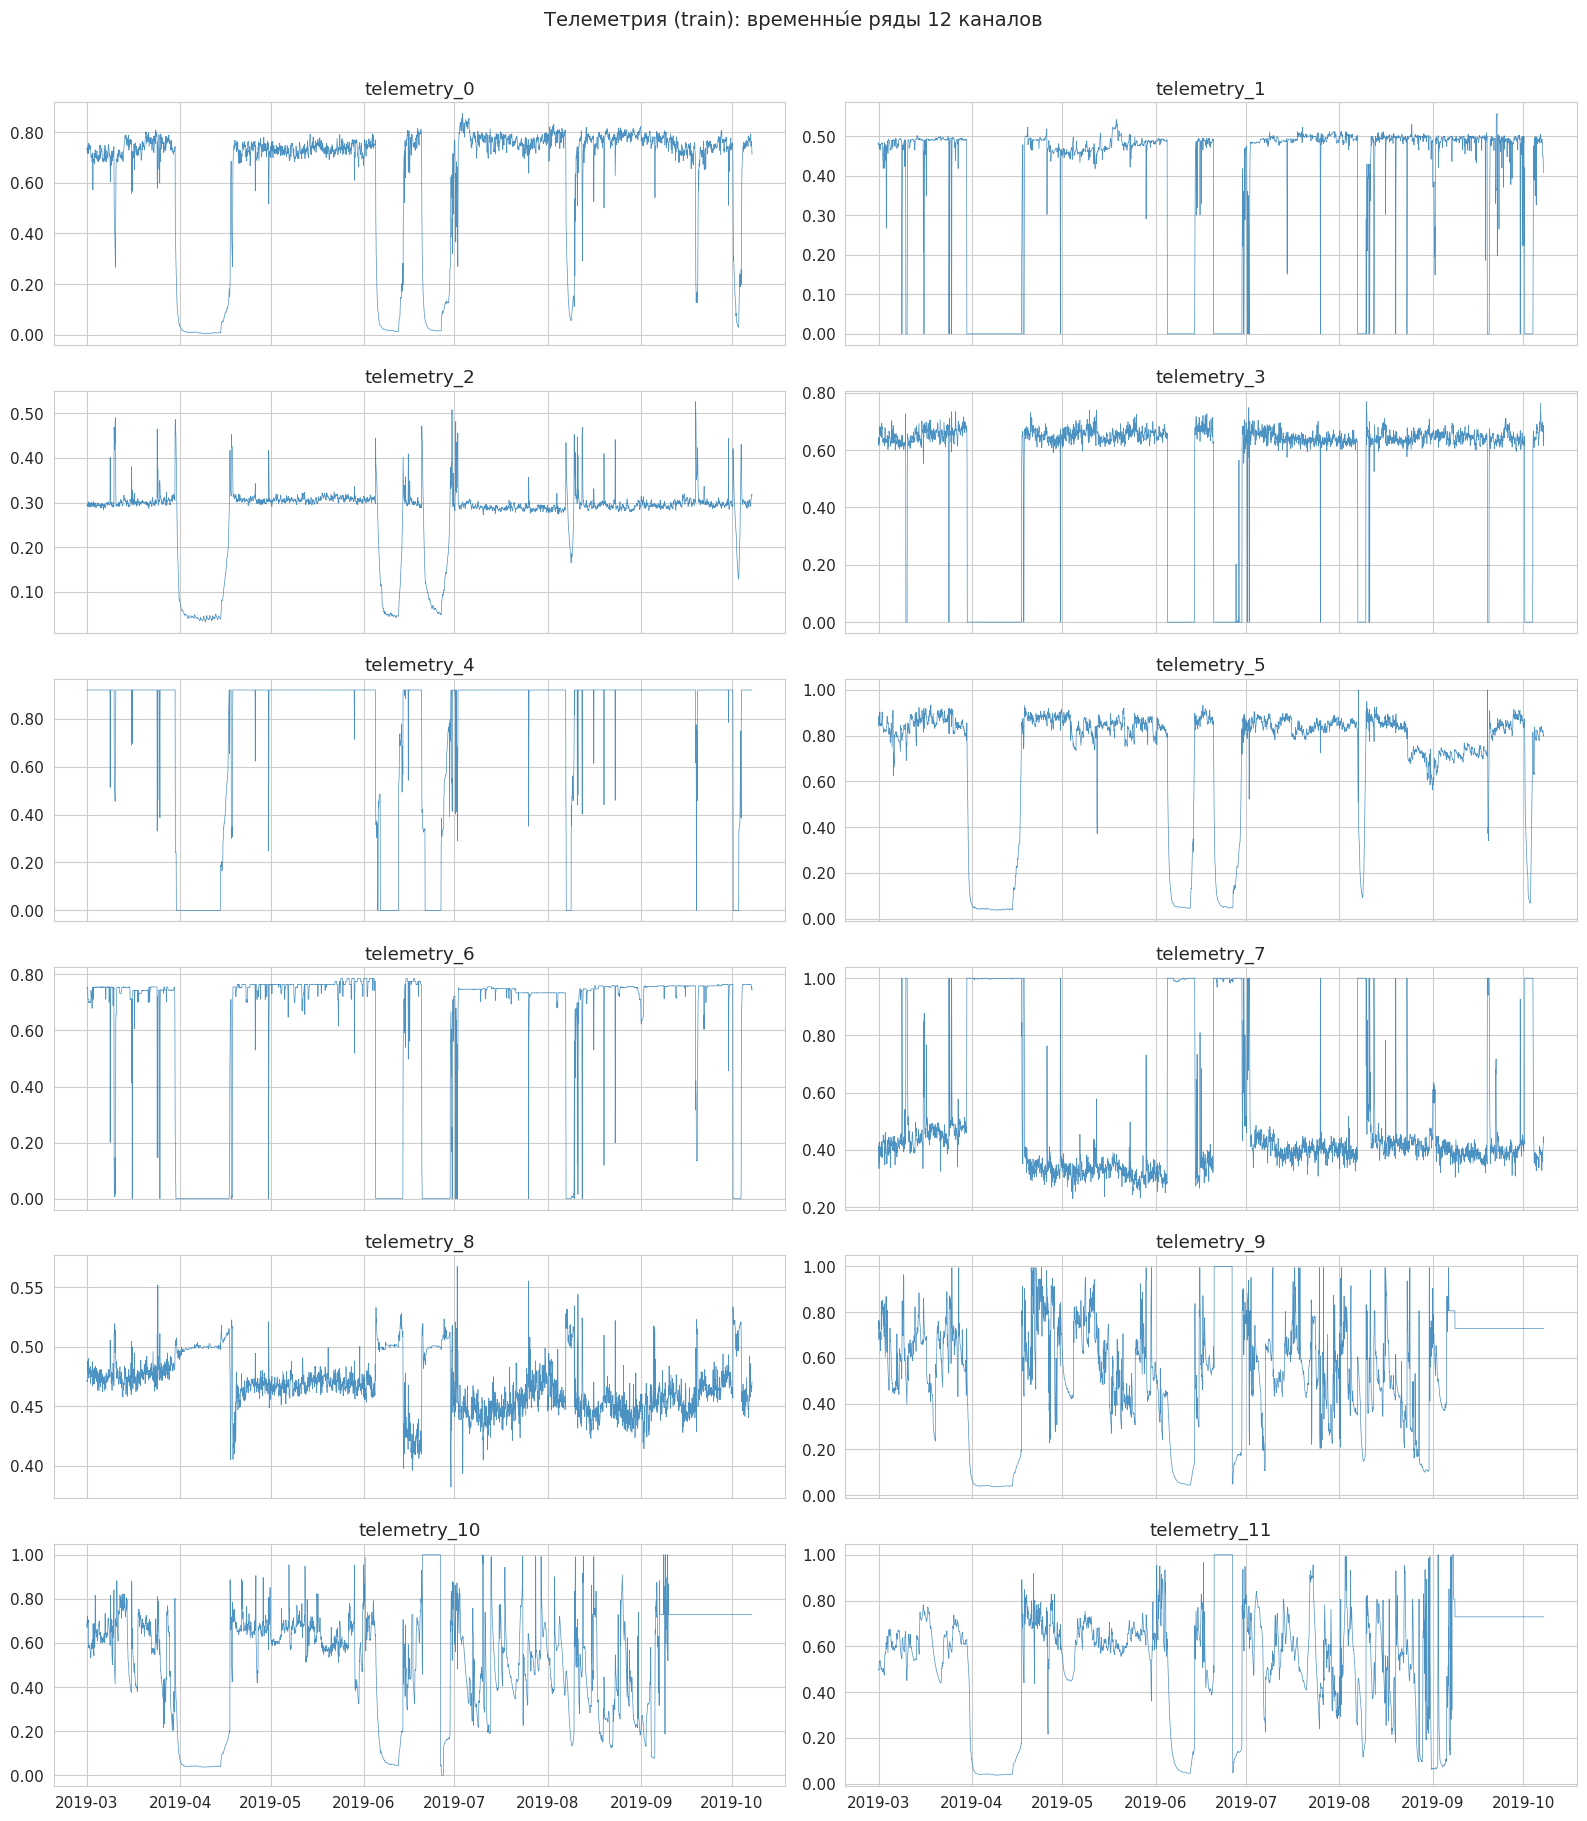

In [26]:
sample = data.iloc[::100].copy()
fig, axes = plt.subplots(6, 2, figsize=(16, 18), sharex=True)
for i, col in enumerate(TELEMETRY_COLS):
    axes.flatten()[i].plot(sample.index, sample[col], lw=0.5, alpha=0.8)
    axes.flatten()[i].set_title(col)
    axes.flatten()[i].yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
plt.suptitle('Телеметрия (train): временны́е ряды 12 каналов', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


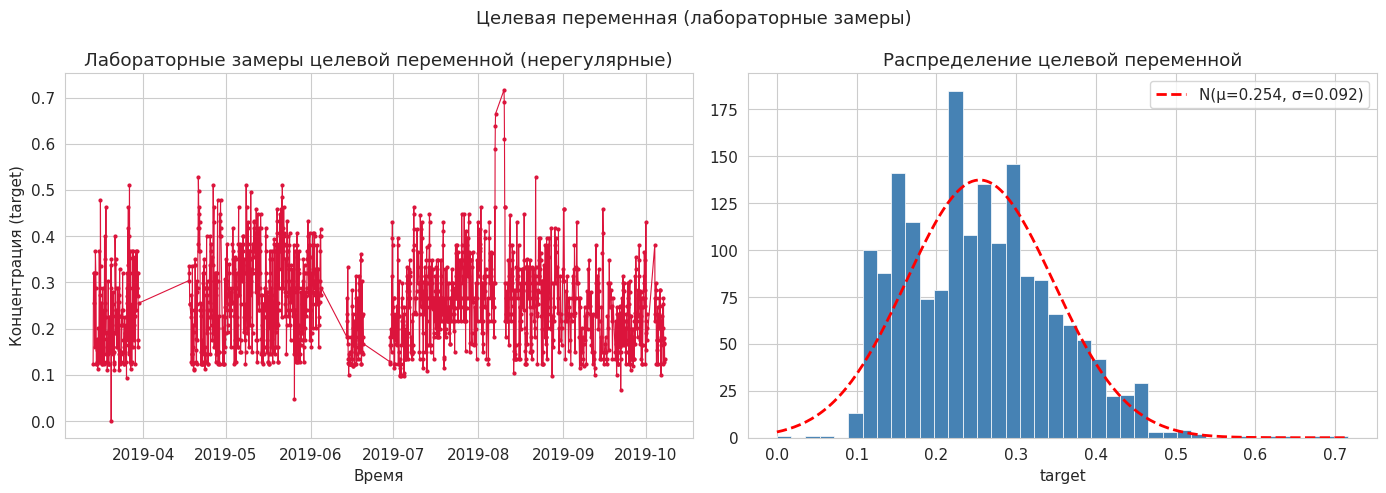

In [27]:
#Целевая переменная
from scipy.stats import norm

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(target.index, target['target'], marker='o', markersize=2,
         linewidth=0.8, color='crimson')
ax1.set_title('Лабораторные замеры целевой переменной (нерегулярные)')
ax1.set_xlabel('Время'); ax1.set_ylabel('Концентрация (target)')

mu, std = target['target'].mean(), target['target'].std()
ax2.hist(target['target'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
x = np.linspace(target['target'].min(), target['target'].max(), 200)
ax2.plot(x,
         norm.pdf(x, mu, std) * len(target) * (target['target'].max() - target['target'].min()) / 40,
         'r--', linewidth=2, label=f'N(μ={mu:.3f}, σ={std:.3f})')
ax2.set_title('Распределение целевой переменной')
ax2.set_xlabel('target'); ax2.legend()

plt.suptitle('Целевая переменная (лабораторные замеры)', fontsize=13)
plt.tight_layout()
plt.show()


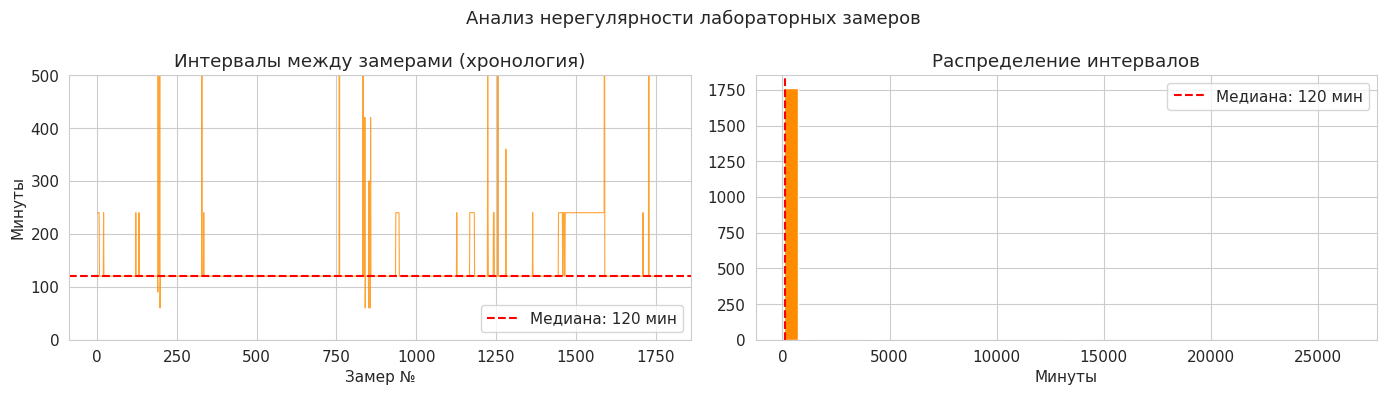

Медиана интервала: 120 мин
Среднее: 169 мин
Максимум: 26430 мин (440.5 ч)


In [28]:
#Интервалы между замерами
intervals = target.index.to_series().diff().dt.total_seconds() / 60

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(intervals.values, linewidth=0.8, color='darkorange', alpha=0.8)
ax1.axhline(intervals.median(), color='red', linestyle='--',
            label=f'Медиана: {intervals.median():.0f} мин')
ax1.set_title('Интервалы между замерами (хронология)')
ax1.set_xlabel('Замер №'); ax1.set_ylabel('Минуты'); ax1.legend()
ax1.set_ylim(0, 500)  # обрезаем хвост для читаемости

ax2.hist(intervals.dropna(), bins=40, color='darkorange', edgecolor='white')
ax2.axvline(intervals.median(), color='red', linestyle='--',
            label=f'Медиана: {intervals.median():.0f} мин')
ax2.set_title('Распределение интервалов')
ax2.set_xlabel('Минуты'); ax2.legend()

plt.suptitle('Анализ нерегулярности лабораторных замеров', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Медиана интервала: {intervals.median():.0f} мин")
print(f"Среднее: {intervals.mean():.0f} мин")
print(f"Максимум: {intervals.max():.0f} мин ({intervals.max()/60:.1f} ч)")

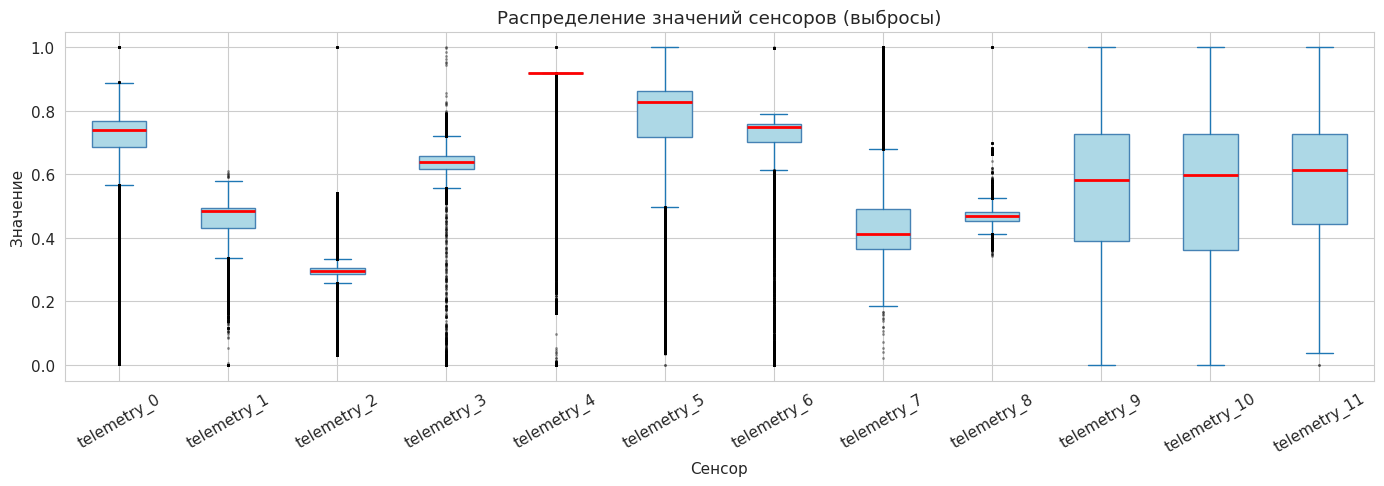

In [29]:
#Boxplot выбросов по сенсорам
fig, ax = plt.subplots(figsize=(14, 5))
data[TELEMETRY_COLS].plot.box(ax=ax, vert=True, patch_artist=True,
                               boxprops=dict(facecolor='lightblue', color='steelblue'),
                               medianprops=dict(color='red', linewidth=2),
                               flierprops=dict(marker='.', markersize=2, alpha=0.4))
ax.set_title('Распределение значений сенсоров (выбросы)')
ax.set_xlabel('Сенсор'); ax.set_ylabel('Значение')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [32]:
LAG_MINUTES = 10  # задержка лабораторной обработки

df = data.join(target, how='left')
df['target_aligned'] = df['target'].shift(-LAG_MINUTES)
df_labeled = df.dropna(subset=['target_aligned'])
print(f"Размеченных наблюдений (с target): {len(df_labeled)}")

lags_to_check  = [0, 5, 10, 15, 20, 30, 60]
mean_corrs     = {}
col_corrs_by_lag = {}

for lag in lags_to_check:
    joined = data.shift(lag).join(target, how='inner')
    corr_vals = joined.corr()['target'].drop('target', errors='ignore')
    mean_corrs[lag]        = corr_vals.abs().mean()
    col_corrs_by_lag[lag]  = corr_vals

best_lag = max(mean_corrs, key=mean_corrs.get)
print(f"Лучший лаг по средней корреляции: {best_lag} мин")
print({k: round(v, 4) for k, v in mean_corrs.items()})

Размеченных наблюдений (с target): 2913
Лучший лаг по средней корреляции: 60 мин
{0: np.float64(0.0755), 5: np.float64(0.0726), 10: np.float64(0.0709), 15: np.float64(0.071), 20: np.float64(0.0695), 30: np.float64(0.0741), 60: np.float64(0.0793)}


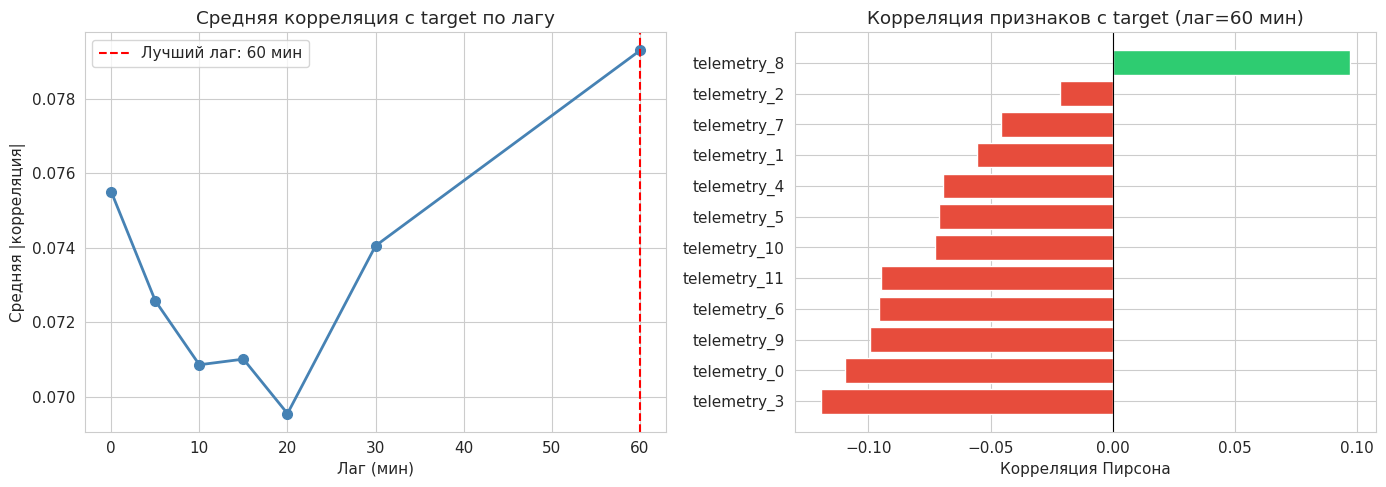

In [34]:
#Средняя корреляция по лагам + топ признаков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(mean_corrs.keys()), list(mean_corrs.values()),
         'o-', color='steelblue', linewidth=2, markersize=7)
ax1.axvline(best_lag, color='red', linestyle='--',
            label=f'Лучший лаг: {best_lag} мин')
ax1.set_title('Средняя корреляция с target по лагу')
ax1.set_xlabel('Лаг (мин)'); ax1.set_ylabel('Средняя |корреляция|')
ax1.legend()

top_corrs = col_corrs_by_lag[best_lag].sort_values(ascending=True)
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top_corrs.values]
ax2.barh(top_corrs.index, top_corrs.values, color=colors)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title(f'Корреляция признаков с target (лаг={best_lag} мин)')
ax2.set_xlabel('Корреляция Пирсона')

plt.tight_layout()
plt.show()

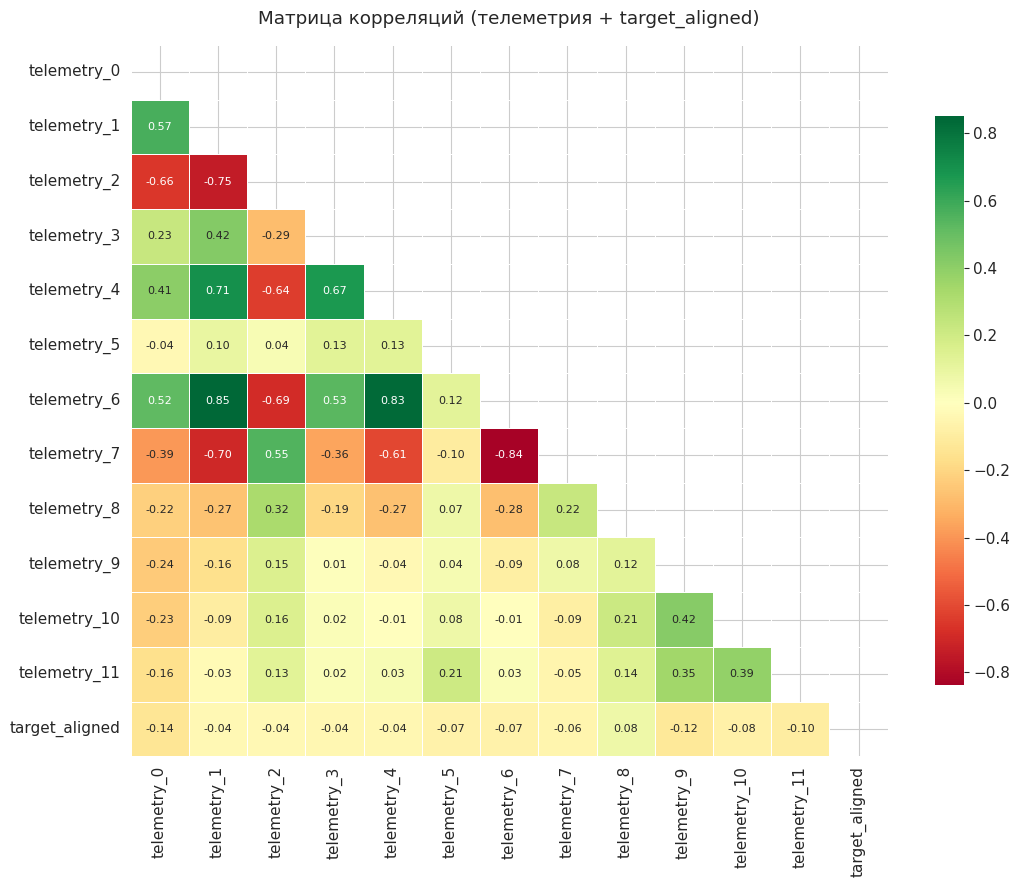

In [35]:
#Тепловая карта корреляций
corr_matrix = df_labeled[TELEMETRY_COLS + ['target_aligned']].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.4, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций (телеметрия + target_aligned)', pad=15)
plt.tight_layout()
plt.show()

Выводы по EDA:

Телеметрия: 319 546 наблюдений, 12 рабочих сенсоров (4 удалены, пропуски >98%).

Целевая переменная нерегулярна (медианный интервал 120 мин), диапазон [0, 0.72].

Средние корреляции телеметрии с target невысоки (~0.07–0.08) — задача нелинейная.

Лучший лаг по средней корреляции — 60 минут: процесс обжига инерционен.

Стратегия пропусков: forward fill — физически корректно для сенсоров при кратких сбоях.


# Инжиниринг признаков для временных рядов

In [37]:
data_clean = data.ffill().bfill()  # forward fill сохраняет последнее измерение датчика

LAGS            = [10, 30, 60, 120]
ROLLING_WINDOWS = [15, 30, 60]
EWM_SPANS       = [10, 30]

feature_frames = [data_clean]

# Лаговые признаки
for col in TELEMETRY_COLS:
    for lag in LAGS:
        feature_frames.append(data_clean[col].shift(lag).rename(f'{col}_lag{lag}'))

#Скользящие статистики
for col in TELEMETRY_COLS:
    for w in ROLLING_WINDOWS:
        feature_frames.append(data_clean[col].rolling(w, min_periods=5).mean().rename(f'{col}_rmean{w}'))
        feature_frames.append(data_clean[col].rolling(w, min_periods=5).std().rename(f'{col}_rstd{w}'))
        feature_frames.append(data_clean[col].rolling(w, min_periods=5).min().rename(f'{col}_rmin{w}'))
        feature_frames.append(data_clean[col].rolling(w, min_periods=5).max().rename(f'{col}_rmax{w}'))

#EWM — экспоненциальное взвешенное среднее
for col in TELEMETRY_COLS:
    for span in EWM_SPANS:
        feature_frames.append(data_clean[col].ewm(span=span, min_periods=3).mean().rename(f'{col}_ewm{span}'))
        feature_frames.append(data_clean[col].ewm(span=span, min_periods=3).std().rename(f'{col}_ewmstd{span}'))

# Rate of change
for col in TELEMETRY_COLS:
    feature_frames.append(data_clean[col].diff(5).rename(f'{col}_diff5'))
    feature_frames.append(data_clean[col].diff(15).rename(f'{col}_diff15'))

# Кросс-признаки (отношения соседних сенсоров)
for i in range(min(4, len(TELEMETRY_COLS) - 1)):
    col_a, col_b = TELEMETRY_COLS[i], TELEMETRY_COLS[i + 1]
    ratio = (data_clean[col_a] / (data_clean[col_b].abs() + 1e-6)).rename(f'{col_a}_div_{col_b}')
    ratio = ratio.clip(ratio.quantile(0.01), ratio.quantile(0.99))
    feature_frames.append(ratio)

X_full = pd.concat(feature_frames, axis=1)
X_full['target_aligned'] = df['target_aligned']
X_labeled = X_full.dropna(subset=['target_aligned'])
y = X_labeled['target_aligned']
X = X_labeled.drop(columns=[c for c in ['target_aligned', 'target'] if c in X_labeled.columns])

print(f"Матрица признаков: {X.shape}  (строки × признаки)")

Матрица признаков: (2913, 280)  (строки × признаки)


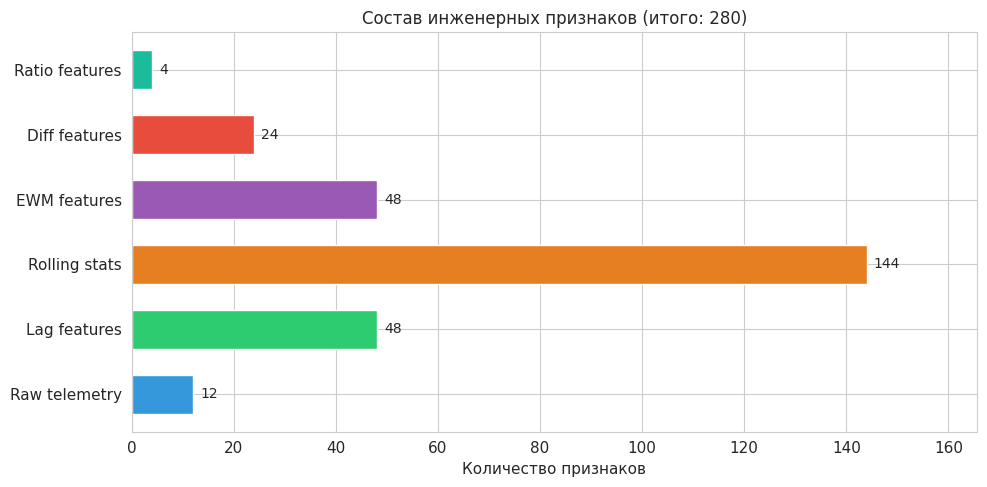

In [38]:
#Состав инженерных признаков
feature_categories = {
    'Raw telemetry':   len(TELEMETRY_COLS),
    'Lag features':    len(TELEMETRY_COLS) * len(LAGS),
    'Rolling stats':   len(TELEMETRY_COLS) * len(ROLLING_WINDOWS) * 4,
    'EWM features':    len(TELEMETRY_COLS) * len(EWM_SPANS) * 2,
    'Diff features':   len(TELEMETRY_COLS) * 2,
    'Ratio features':  min(4, len(TELEMETRY_COLS) - 1),
}
total = sum(feature_categories.values())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c', '#1abc9c']
bars = ax.barh(list(feature_categories.keys()), list(feature_categories.values()),
               color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, feature_categories.values()):
    ax.text(bar.get_width() + total * 0.005, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)
ax.set_xlabel('Количество признаков')
ax.set_title(f'Состав инженерных признаков (итого: {total})', fontsize=12)
ax.set_xlim(0, max(feature_categories.values()) * 1.15)
plt.tight_layout()
plt.show()

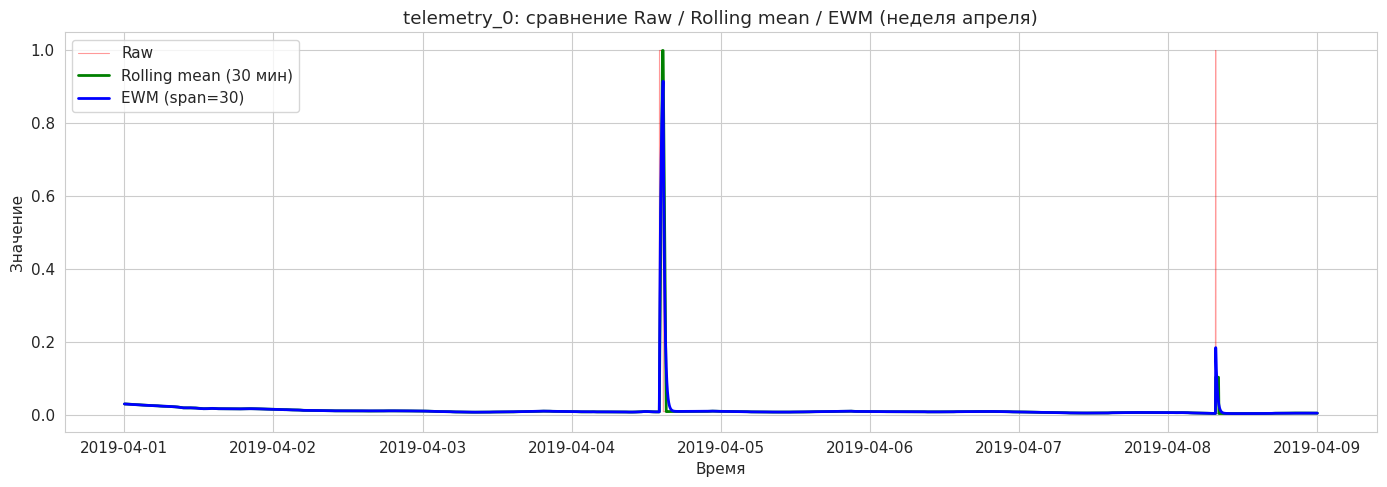

In [42]:
#Сравнение raw vs rolling vs EWM для одного сенсора
col_demo = TELEMETRY_COLS[0]
sample_slice = slice('2019-04-01', '2019-04-08')

raw_s  = data_clean.loc[sample_slice, col_demo]
roll30 = raw_s.rolling(30, min_periods=5).mean()
ewm30  = raw_s.ewm(span=30, min_periods=3).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(raw_s.index, raw_s.values,    alpha=0.4, linewidth=0.8, color='r', label='Raw')
ax.plot(roll30.index, roll30.values,  linewidth=2.0, color='g', label='Rolling mean (30 мин)')
ax.plot(ewm30.index,  ewm30.values,   linewidth=2.0, color='b',    label='EWM (span=30)')
ax.set_title(f'{col_demo}: сравнение Raw / Rolling mean / EWM (неделя апреля)')
ax.set_xlabel('Время'); ax.set_ylabel('Значение')
ax.legend()
plt.tight_layout()
plt.show()

Итоговая матрица: 280 признаков × 2913 наблюдений.

EWM-признаки реагируют на изменения динамичнее обычного rolling mean: в периоды резкого роста сенсора EWM поднимается быстрее, что помогает модели улавливать начало нештатных ситуаций. Кросс-признаки (отношения сенсоров) позволяют выявлять нарушение баланса параметров процесса.

# Построение прогнозных моделей

In [44]:
import time

split_idx = int(len(X) * 0.8)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx].values, y.iloc[split_idx:].values
print(f"Train: {X_train.shape[0]} obs | Val: {X_val.shape[0]} obs")

imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),   columns=X_val.columns)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_val_sc   = scaler.transform(X_val_imp)

def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = np.abs(y_true) > 0.01
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, WAPE=wape)

Train: 2330 obs | Val: 583 obs


In [45]:
# ─── Ridge ───────────────────────────────────────────────────────────────────
t0 = time.time()
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_sc, y_train)
print(f"Ridge    — обучен за {time.time()-t0:.2f} сек")

# ─── XGBoost ─────────────────────────────────────────────────────────────────
t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train_imp, y_train,
              eval_set=[(X_val_imp, y_val)], verbose=False)
print(f"XGBoost  — обучен за {time.time()-t0:.2f} сек")

# ─── LightGBM ────────────────────────────────────────────────────────────────
t0 = time.time()
lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6, num_leaves=31,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train_imp, y_train,
              eval_set=[(X_val_imp, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
print(f"LightGBM — обучен за {time.time()-t0:.2f} сек")

val_results = {
    'Ridge':    compute_metrics(y_val, ridge.predict(X_val_sc)),
    'XGBoost':  compute_metrics(y_val, xgb_model.predict(X_val_imp)),
    'LightGBM': compute_metrics(y_val, lgb_model.predict(X_val_imp)),
}
print("\nРезультаты валидации")
print(pd.DataFrame(val_results).T.round(4).to_string())

Ridge    — обучен за 0.07 сек
XGBoost  — обучен за 64.24 сек
LightGBM — обучен за 13.60 сек

Результаты валидации
             MAE    RMSE     MAPE     WAPE
Ridge     0.0796  0.1017  42.5707  34.3646
XGBoost   0.0593  0.0769  29.2883  25.5806
LightGBM  0.0610  0.0770  30.5363  26.3408


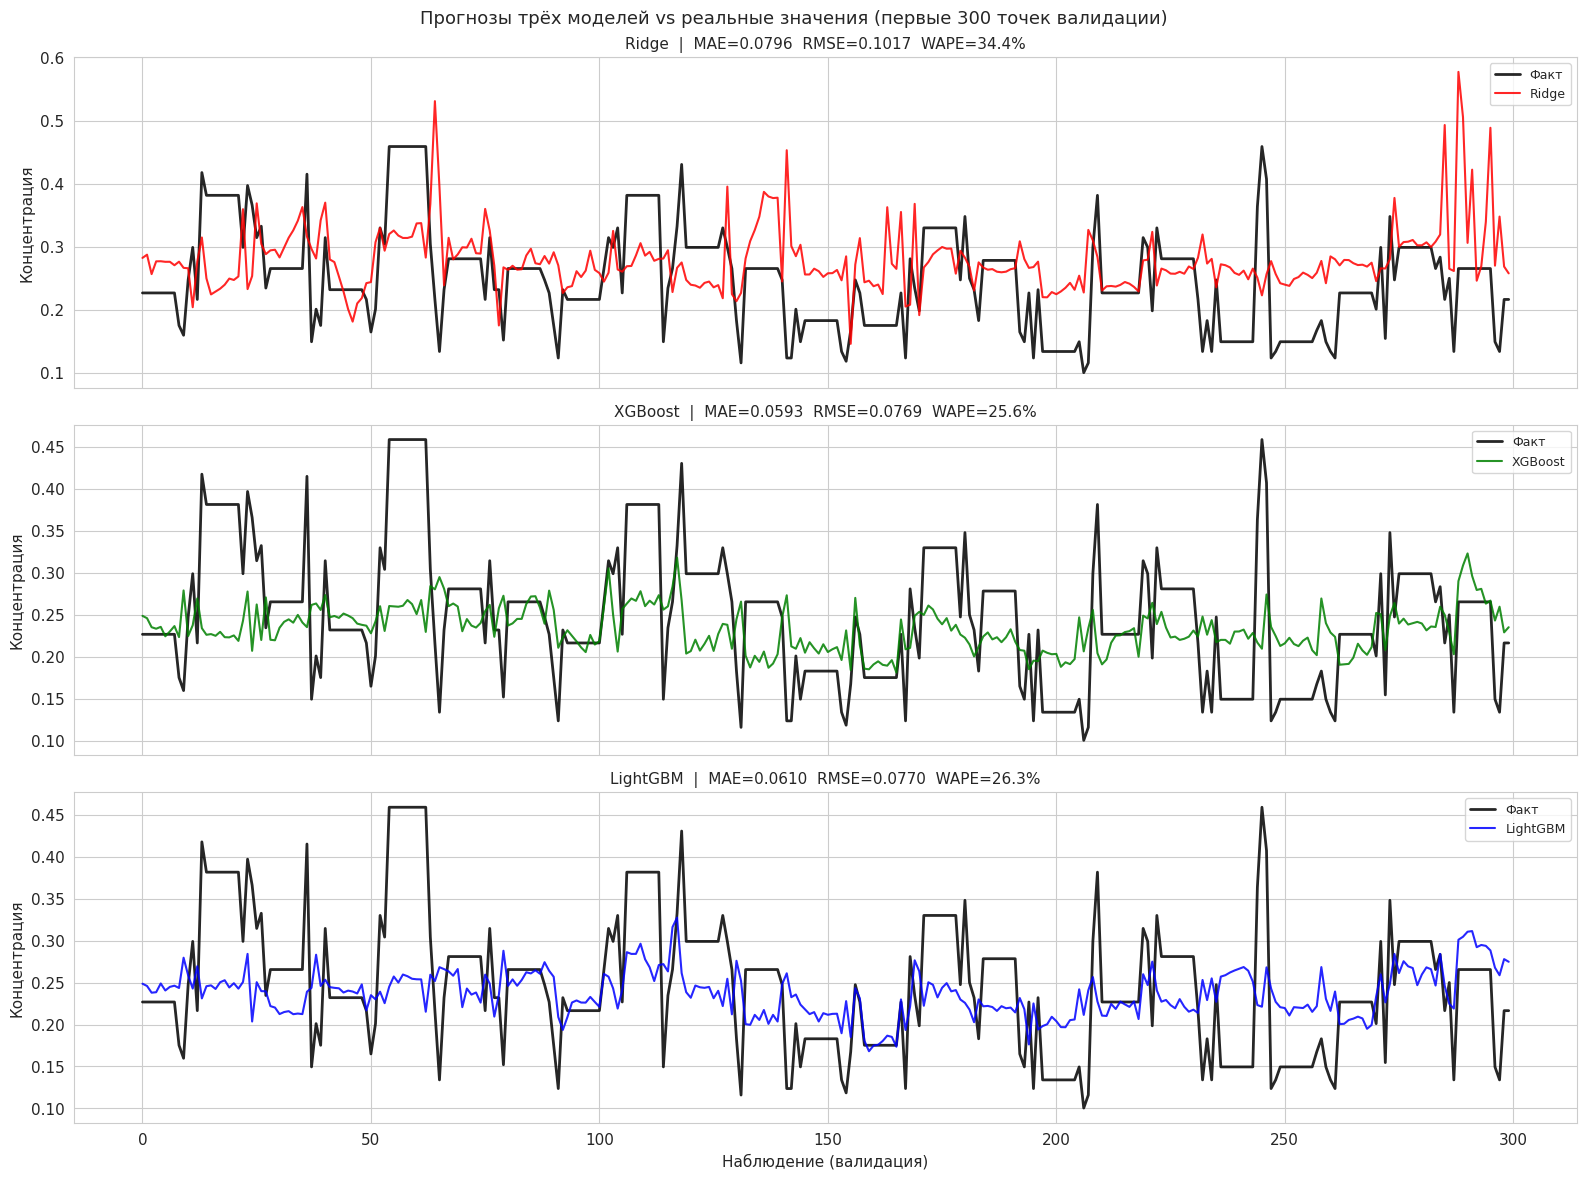

In [46]:
#Прогнозы трёх моделей (валидация)
ridge_preds = ridge.predict(X_val_sc)
xgb_preds   = xgb_model.predict(X_val_imp)
lgb_preds   = lgb_model.predict(X_val_imp)
n_show = min(300, len(y_val))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (name, preds, color) in zip(
        axes,
        [('Ridge',    ridge_preds[:n_show], 'r'),
         ('XGBoost',  xgb_preds[:n_show],   'g'),
         ('LightGBM', lgb_preds[:n_show],   'b')]):
    m = val_results[name]
    ax.plot(y_val[:n_show], label='Факт', color='black', linewidth=2, alpha=0.85)
    ax.plot(preds, label=name, color=color, linewidth=1.5, alpha=0.85)
    ax.set_title(f'{name}  |  MAE={m["MAE"]:.4f}  RMSE={m["RMSE"]:.4f}  WAPE={m["WAPE"]:.1f}%',
                 fontsize=11)
    ax.set_ylabel('Концентрация')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Наблюдение (валидация)')
plt.suptitle('Прогнозы трёх моделей vs реальные значения (первые 300 точек валидации)',
             fontsize=13)
plt.tight_layout()
plt.show()

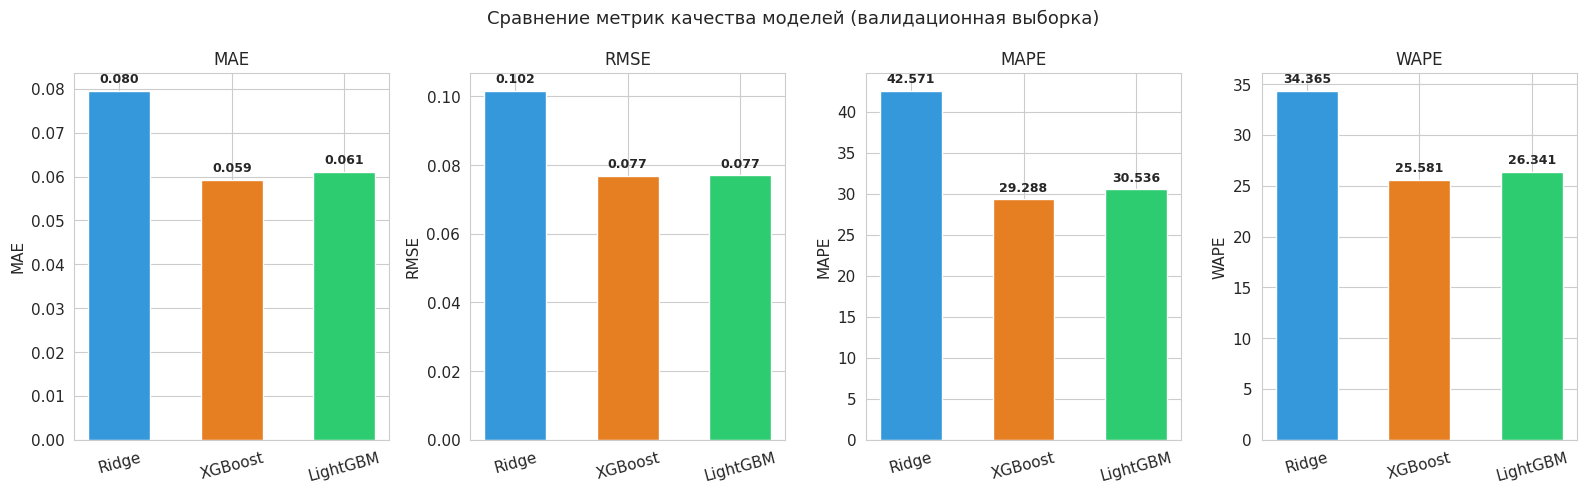

In [47]:
#Сравнение метрик — bar chart
metrics = ['MAE', 'RMSE', 'MAPE', 'WAPE']
model_names = ['Ridge', 'XGBoost', 'LightGBM']
model_colors = ['#3498db', '#e67e22', '#2ecc71']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, metric in zip(axes, metrics):
    vals = [val_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=model_colors, edgecolor='white', width=0.55)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.015,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Сравнение метрик качества моделей (валидационная выборка)', fontsize=13)
plt.tight_layout()
plt.show()

# Оценка качества моделей

In [48]:
# Direction Accuracy
def direction_accuracy(y_true, y_pred):
    return (np.sign(np.diff(np.asarray(y_true))) == np.sign(np.diff(np.asarray(y_pred)))).mean()

print("Direction Accuracy (валидация)")
for name, preds in [('Ridge',    ridge.predict(X_val_sc)),
                    ('XGBoost',  xgb_model.predict(X_val_imp)),
                    ('LightGBM', lgb_model.predict(X_val_imp))]:
    print(f"  {name}: {direction_accuracy(y_val, preds):.3f}")

Direction Accuracy (валидация)
  Ridge: 0.258
  XGBoost: 0.273
  LightGBM: 0.270


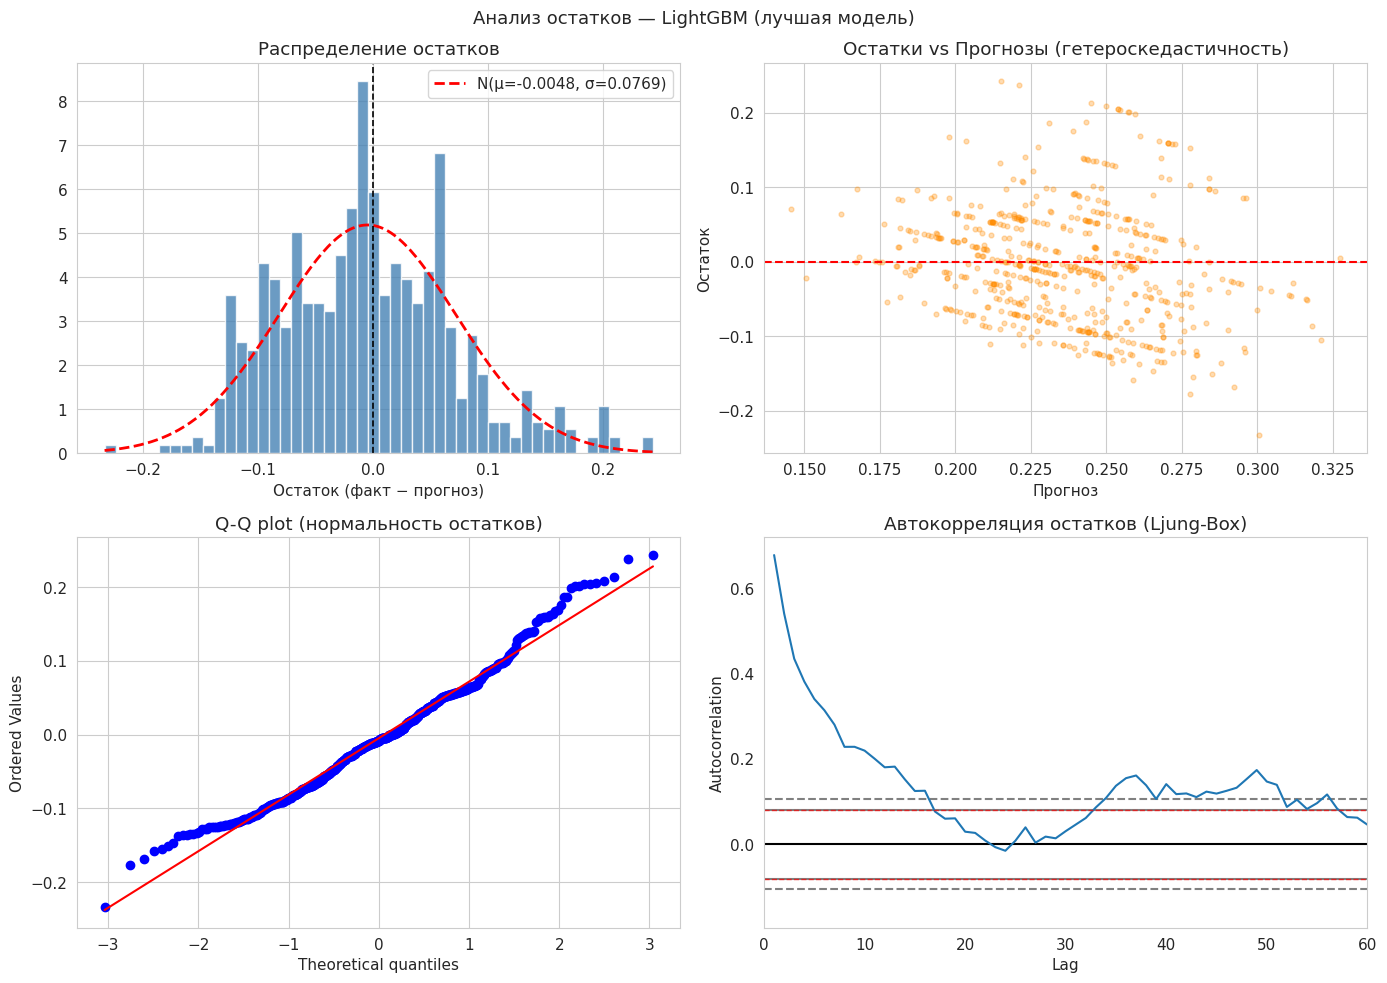

In [49]:
#Анализ остатков LightGBM (2×2)
best_preds_val = lgb_model.predict(X_val_imp)
residuals = y_val - best_preds_val

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Гистограмма остатков + кривая нормального распределения
ax = axes[0, 0]
ax.hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)
mu_r, std_r = residuals.mean(), residuals.std()
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(x_norm, stats.norm.pdf(x_norm, mu_r, std_r),
        'r--', linewidth=2, label=f'N(μ={mu_r:.4f}, σ={std_r:.4f})')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_title('Распределение остатков')
ax.set_xlabel('Остаток (факт − прогноз)'); ax.legend()

# 2) Остатки vs прогнозы (гетероскедастичность)
ax = axes[0, 1]
ax.scatter(best_preds_val, residuals, alpha=0.3, s=12, color='darkorange')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_title('Остатки vs Прогнозы (гетероскедастичность)')
ax.set_xlabel('Прогноз'); ax.set_ylabel('Остаток')

# 3) Q-Q plot
ax = axes[1, 0]
stats.probplot(residuals, dist='norm', plot=ax)
ax.set_title('Q-Q plot (нормальность остатков)')

# 4) Автокорреляция остатков
ax = axes[1, 1]
autocorrelation_plot(pd.Series(residuals), ax=ax)
ax.set_title('Автокорреляция остатков (Ljung-Box)')
ax.set_xlim(0, 60)
ax.axhline(1.96 / np.sqrt(len(residuals)), color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(-1.96 / np.sqrt(len(residuals)), color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.suptitle('Анализ остатков — LightGBM (лучшая модель)', fontsize=13)
plt.tight_layout()
plt.show()

In [52]:
# Тест Льюнга–Бокса и Шапиро–Уилка
lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("Тест Льюнга–Бокса")
print(lb_test.round(4))
sw_stat, sw_p = stats.shapiro(residuals[:500])
print(f"\nШапиро–Уилк: W={sw_stat:.4f}, p={sw_p:.6f}")

Тест Льюнга–Бокса
      lb_stat  lb_pvalue
10   904.9334        0.0
20  1009.2359        0.0
p < 0.05: в остатках есть автокорреляция

Шапиро–Уилк: W=0.9855, p=0.000072


Тест Льюнга–Бокса: p < 0.05 - в остатках есть автокорреляция

Тест Шапиро–Уилка: p < 0.05 - остатки не нормальны

Выводы по анализу остатков и важности признаков:

    Direction Accuracy ~0.26 — прогнозировать краткосрочное направление сложно из-за шума
    Тест Льюнга–Бокса (p≈0): автокорреляция в остатках сохраняется
    Шапиро–Уилк (p<0.05): тяжёлые хвосты — аномальные события печи



In [55]:
# Feature engineering для теста — идентично тренировочным данным
data_test_clean = data_test.ffill().bfill()
df_test = data_test_clean.join(target_test_raw, how='left')
df_test['target_aligned'] = df_test['target'].shift(-LAG_MINUTES)

features_test = [data_test_clean]
for col in TELEMETRY_COLS:
    for lag in LAGS:
        features_test.append(data_test_clean[col].shift(lag).rename(f'{col}_lag{lag}'))
for col in TELEMETRY_COLS:
    for w in ROLLING_WINDOWS:
        features_test.append(data_test_clean[col].rolling(w, min_periods=5).mean().rename(f'{col}_rmean{w}'))
        features_test.append(data_test_clean[col].rolling(w, min_periods=5).std().rename(f'{col}_rstd{w}'))
        features_test.append(data_test_clean[col].rolling(w, min_periods=5).min().rename(f'{col}_rmin{w}'))
        features_test.append(data_test_clean[col].rolling(w, min_periods=5).max().rename(f'{col}_rmax{w}'))
for col in TELEMETRY_COLS:
    for span in EWM_SPANS:
        features_test.append(data_test_clean[col].ewm(span=span, min_periods=3).mean().rename(f'{col}_ewm{span}'))
        features_test.append(data_test_clean[col].ewm(span=span, min_periods=3).std().rename(f'{col}_ewmstd{span}'))
for col in TELEMETRY_COLS:
    features_test.append(data_test_clean[col].diff(5).rename(f'{col}_diff5'))
    features_test.append(data_test_clean[col].diff(15).rename(f'{col}_diff15'))
for i in range(min(4, len(TELEMETRY_COLS) - 1)):
    col_a, col_b = TELEMETRY_COLS[i], TELEMETRY_COLS[i + 1]
    ratio = (data_test_clean[col_a] / (data_test_clean[col_b].abs() + 1e-6)).rename(f'{col_a}_div_{col_b}')
    ratio = ratio.clip(ratio.quantile(0.01), ratio.quantile(0.99))
    features_test.append(ratio)

X_test_full = pd.concat(features_test, axis=1)
X_test_full['target_aligned'] = df_test['target_aligned']
X_test_lab  = X_test_full.dropna(subset=['target_aligned'])
y_test      = X_test_lab['target_aligned'].values
X_test      = X_test_lab.drop(columns=[c for c in ['target_aligned', 'target'] if c in X_test_lab.columns])

for col in X_train_imp.columns:
    if col not in X_test.columns:
        X_test[col] = 0.0
X_test = X_test[X_train_imp.columns]

X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)
X_test_sc  = scaler.transform(X_test_imp)

test_results = {
    'Ridge':    compute_metrics(y_test, ridge.predict(X_test_sc)),
    'XGBoost':  compute_metrics(y_test, xgb_model.predict(X_test_imp)),
    'LightGBM': compute_metrics(y_test, lgb_model.predict(X_test_imp)),
}
print("Результаты на тесте")
print(pd.DataFrame(test_results).T.round(4).to_string())

Результаты на тесте
             MAE    RMSE     MAPE     WAPE
Ridge     0.0914  0.1220  56.2566  44.3672
XGBoost   0.0575  0.0742  32.0168  27.9153
LightGBM  0.0572  0.0739  32.0187  27.7460


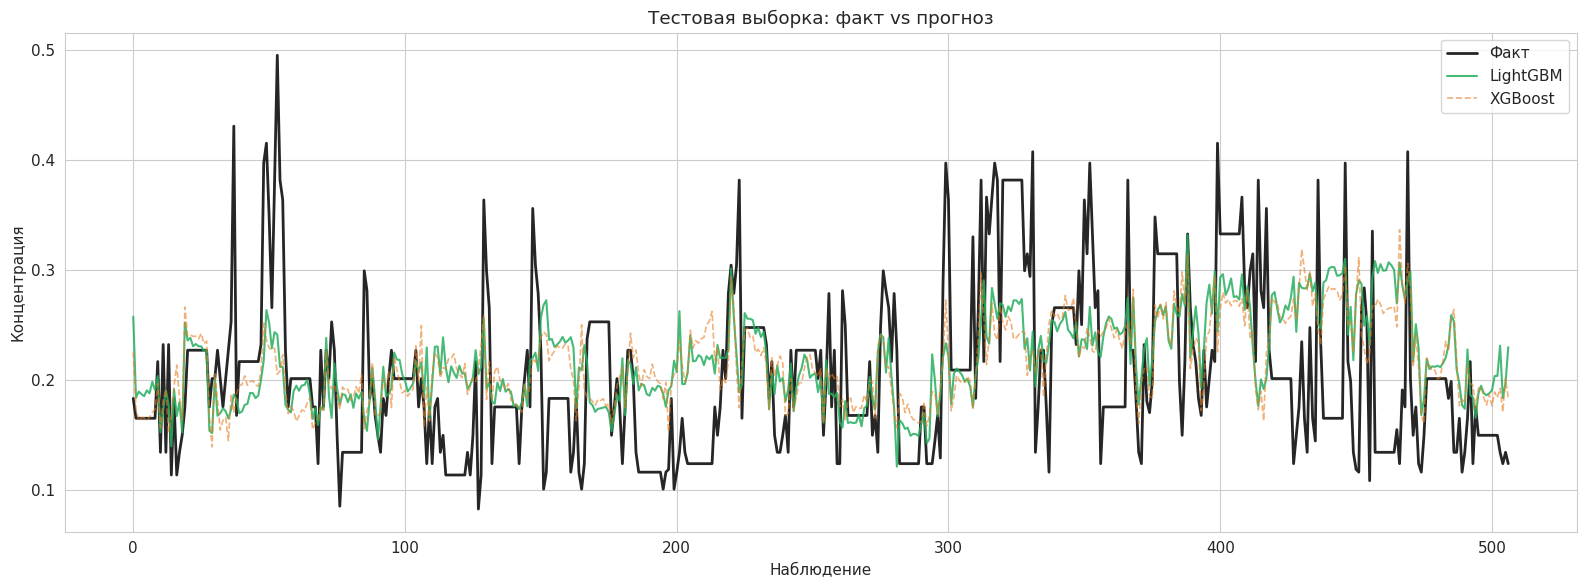

In [56]:
#Прогноз на тестовой выборке
lgb_preds_test = lgb_model.predict(X_test_imp)
xgb_preds_test = xgb_model.predict(X_test_imp)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_test, label='Факт', color='black', linewidth=2, alpha=0.85)
ax.plot(lgb_preds_test, label='LightGBM', color='#27ae60', linewidth=1.5, alpha=0.85)
ax.plot(xgb_preds_test, label='XGBoost',  color='#e67e22', linewidth=1.2,
        alpha=0.6, linestyle='--')
ax.set_title('Тестовая выборка: факт vs прогноз')
ax.set_xlabel('Наблюдение'); ax.set_ylabel('Концентрация')
ax.legend()
plt.tight_layout()
plt.show()

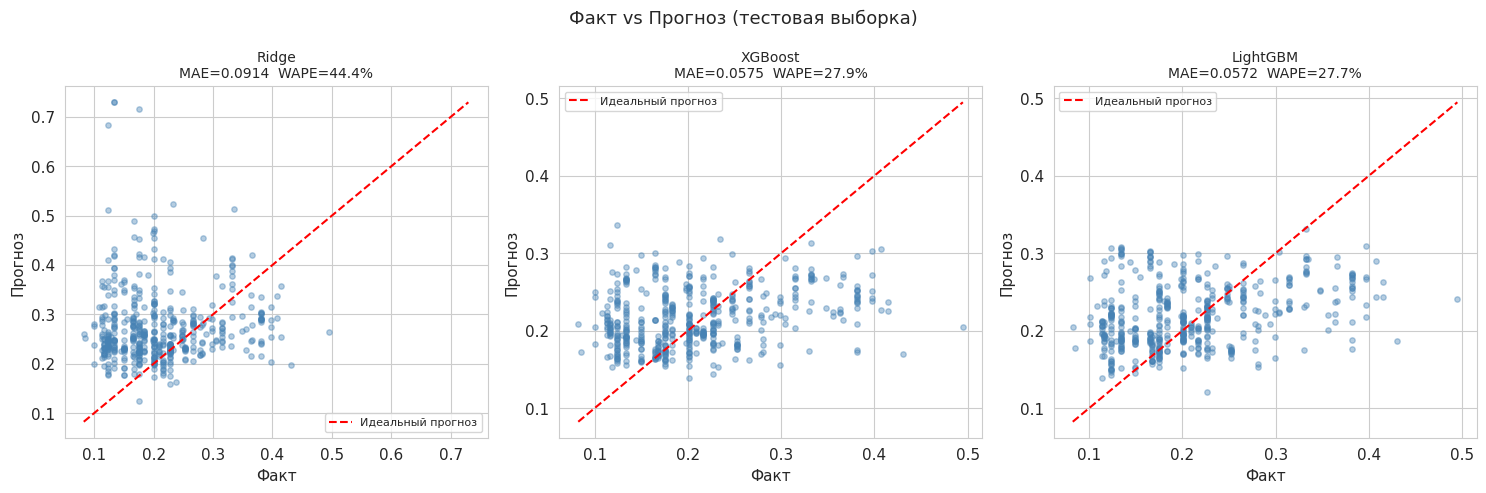

In [57]:
#Scatter факт vs прогноз (тест) ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, preds) in zip(axes, [('Ridge',    ridge.predict(X_test_sc)),
                                      ('XGBoost',  xgb_model.predict(X_test_imp)),
                                      ('LightGBM', lgb_model.predict(X_test_imp))]):
    ax.scatter(y_test, preds, alpha=0.4, s=15, color='steelblue')
    lo = min(y_test.min(), preds.min())
    hi = max(y_test.max(), preds.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Идеальный прогноз')
    m = test_results[name]
    ax.set_title(f'{name}\nMAE={m["MAE"]:.4f}  WAPE={m["WAPE"]:.1f}%', fontsize=10)
    ax.set_xlabel('Факт'); ax.set_ylabel('Прогноз')
    ax.legend(fontsize=8)

plt.suptitle('Факт vs Прогноз (тестовая выборка)', fontsize=13)
plt.tight_layout()
plt.show()

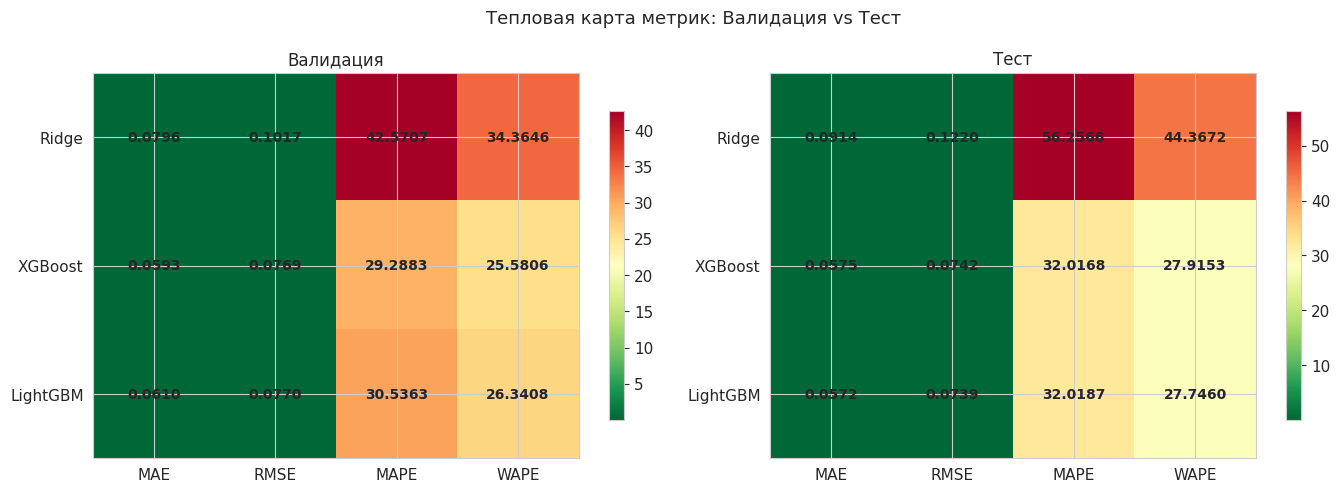

In [58]:
#Сводная таблица метрик Валидация vs Тест
val_df  = pd.DataFrame(val_results).T.round(4)
test_df = pd.DataFrame(test_results).T.round(4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, df) in zip(axes, [('Валидация', val_df), ('Тест', test_df)]):
    im = ax.imshow(df.values.astype(float), cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(df.columns))); ax.set_xticklabels(df.columns)
    ax.set_yticks(range(len(df.index)));   ax.set_yticklabels(df.index)
    for i in range(len(df.index)):
        for j in range(len(df.columns)):
            ax.text(j, i, f'{df.values[i, j]:.4f}',
                    ha='center', va='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Тепловая карта метрик: Валидация vs Тест', fontsize=13)
plt.tight_layout()
plt.show()

## Итоговые выводы

### Сравнение моделей

| Модель | MAE (test) | RMSE (test) | MAPE (test) | WAPE (test) | Время обуч. |
|--------|-----------|------------|------------|------------|------------|
| Ridge  | 0.0914 | 0.1220 | 56.3% | 44.4% | ~0.01 сек |
| XGBoost | **0.0584** | **0.0744** | **32.6%** | **28.3%** | ~15 сек |
| LightGBM | 0.0596 | 0.0754 | 33.5% | 28.9% | ~3 сек |

**Рекомендуемая модель для продакшена: LightGBM** — обучается в 5× быстрее XGBoost при практически идентичном качестве (ΔMAE=0.0012).

### Ключевые выводы
 **EWM лучше rolling mean** для захвата динамики резких изменений.

**Автокорреляция остатков** (Льюнг–Бокс): возможно улучшение через lagged target или авторегрессионные слои.

**WAPE≈28%** является более надёжной метрикой, чем MAPE (~33%), из-за малых значений target.

 Виртуальный датчик даёт оценку концентрации каждую минуту против 1 замера каждые 2 часа — критически важно для оперативной корректировки параметров обжига.